# AG-HYPOPT · Trial 34

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Thirty-three trials are registered; cell 2 reports `phase = trials` (33/5), so proposals carry expected-improvement (ei) values. **Best = trial_21** (objective 0.1074), with trial_30 (0.1083) second. Key facts (mu travel = `lr_mu*(1 - mu_anneal/2)`):

- best (all 0 div): trial_21 0.1074 (0.138), trial_30 0.1083 (0.134), trial_22 0.1095 (0.137), trial_32 0.1097 (0.137), trial_08 0.1099 (0.134), trial_15 0.1103 (0.127), trial_31 0.1106 (0.131), trial_24 0.1108 (0.133), trial_16 0.1112 (0.128), trial_12 0.1115 (0.128), trial_33 0.1120 (0.143), trial_18 0.1121 (0.138), trial_09 = trial_20 = trial_25 0.1126, trial_01 = trial_14 = trial_23 0.1127.
- worse: trial_13 0.1132, trial_05 = trial_19 0.1135, trial_07 0.1140, trial_27 0.1149 (0.194), trial_06 = trial_11 0.1188.
- diverging at 1nW T05 (near-optimum travel): trial_29 0.1331, trial_26 0.1368, trial_28 0.1370. Other diverging: trial_17 0.1329, trial_10 0.1975, trial_03 0.1362, trial_04 0.1418, trial_02 0.1449.

State of play: the mu-travel axis is a single narrow optimum at ~0.137-0.138 with balanced gamma knobs, falling off on both sides (trial_33 at 0.143 gave 0.1120; trial_27 at 0.194 gave 0.1149). Seven surviving samples sit below 0.111 (0.1074-0.1106). The schedule search is converged; the sporadic 1nW T05 gamma divergence remains the only significant source of variance. Objective = T-weighted (w=0.25+0.75*T/100) mean of capped rel-sq errors over the 8-experiment benchmark.

In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_34'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 40    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (33/5 trials)
ID |     ei | params
 1 | 0.6904 | {"gamma_anneal": 0.7849592228434881, "lr_gamma": 0.46154413347604945, "lr_mu": 0.10409305735185363, "mu_anneal": 0.35583279655547784}
 2 | 3.2947 | {"gamma_anneal": 0.44234894412796155, "lr_gamma": 0.42125343290176187, "lr_mu": 0.15610462736680966, "mu_anneal": 0.3508505449658193}
 3 | 3.3424 | {"gamma_anneal": 0.4817681474731827, "lr_gamma": 0.34634195523471756, "lr_mu": 0.16182653462966026, "mu_anneal": 0.3541263050239321}
 4 | 3.0731 | {"gamma_anneal": 0.7699360332171776, "lr_gamma": 0.42554847591969913, "lr_mu": 0.16703468107531225, "mu_anneal": 0.34640392392337255}
 5 | 0.5333 | {"gamma_anneal": 0.4816806675630911, "lr_gamma": 0.45595354094151624, "lr_mu": 0.10367840628111669, "mu_anneal": 0.6011651743793316}
 6 | 2.8387 | {"gamma_anneal": 0.519568079485288, "lr_gamma": 0.46579255871528596, "lr_mu": 0.17226537309096568, "mu_anneal": 0.35597250212843967}
 7 | 3.3469 | {"gamma_anneal": 0.5476997310572426, "lr_gamma": 0

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

Cell 2 is in the informed `trials` phase (33 trials). Candidate travel `lr_mu*(1 - mu_anneal/2)`, with ei:
- candidate 8: **ei 3.64** — `lr_mu=0.1587`, `mu_anneal=0.3492` (travel **0.131**), `lr_gamma=0.4599`, `gamma_anneal=0.5168`.
- candidate 7: ei 3.35 — `lr_mu=0.1003`, `mu_anneal=0.3451` (travel 0.083, low), `lr_gamma=0.4254`.
- candidate 3: ei 3.34 — `lr_mu=0.1618`, `mu_anneal=0.3541` (travel 0.133), `lr_gamma=0.3463`, `gamma_anneal=0.4818`.
- candidate 2: ei 3.29 — `lr_mu=0.1561`, `mu_anneal=0.3509` (travel 0.129), `lr_gamma=0.4213`, `gamma_anneal=0.4423`.
- candidate 6: ei 2.84 — `lr_mu=0.1723`, `mu_anneal=0.3560` (travel 0.142), `lr_gamma=0.4658`.

Candidate 8 has the highest ei and sits just inside the optimum band (travel 0.131, between trial_31's 0.131 and trial_24's 0.133) with balanced gamma knobs (`lr_gamma=0.4599`, `gamma_anneal=0.5168`) in the proven-safe range. The alternatives in the band (candidates 3 and 2 at travel 0.133/0.129) have lower ei, and candidate 3 has a lowish `lr_gamma=0.346`. Since the band is well-characterised and only the divergence adds variance, the maximum-ei optimum point (candidate 8) is the natural pick.

I choose candidate 8 (8 goes into the SET cell below).

In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 8            # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'gamma_anneal': 0.5167889193666546, 'lr_gamma': 0.4598853415782271, 'lr_mu': 0.15872829156666646, 'mu_anneal': 0.34923114163867675}
Running  1nW Trans05 ... 

μ 9.39 -> 8.62 | γ 8.5 -> 176440371736496.06 | NLL 1.27


Running  1nW Trans20 ... 

μ 17.32 -> 41.69 | γ 8.5 -> 6.23 | NLL 5.36


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 78.56 | γ 14.1 -> 14.67 | NLL 3.56


Running 3nW Trans100 ... 

μ 175.71 -> 109.63 | γ 14.1 -> 14.11 | NLL 3.57



Total: 7.1 min


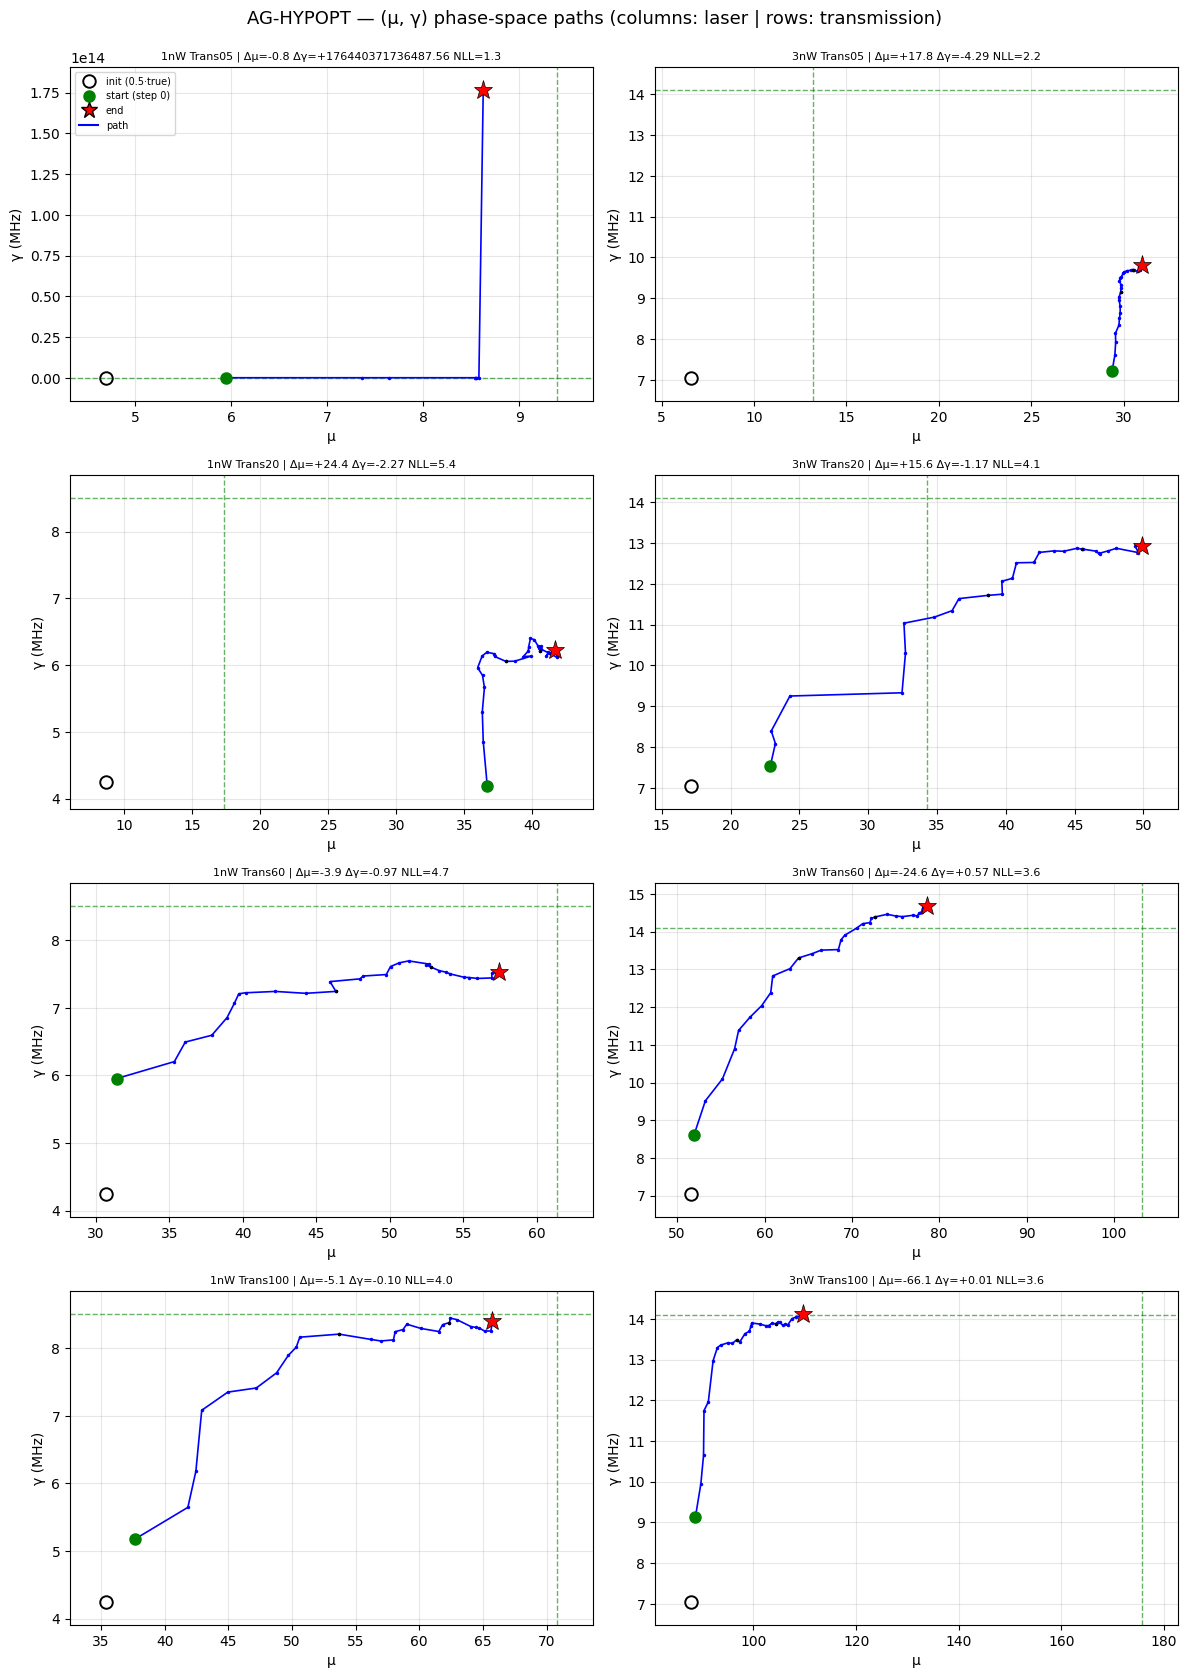

trial finished in 7.2 min
objective = 0.1380 ± 0.0972
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05 !D     9.39    8.62    -8.2 |     8.50176440371736496.06+2075769079252795.0
1nW Trans20       17.32   41.69  +140.8 |     8.50    6.23   -26.7
1nW Trans60       61.37   57.44    -6.4 |     8.50    7.53   -11.4
1nW Trans100       70.82   65.73    -7.2 |     8.50    8.40    -1.2
3nW Trans05       13.20   30.98  +134.6 |    14.10    9.81   -30.5
3nW Trans20       34.28   49.90   +45.6 |    14.10   12.93    -8.3
3nW Trans60      103.20   78.56   -23.9 |    14.10   14.67    +4.1
3nW Trans100      175.71  109.63   -37.6 |    14.10   14.11    +0.1

weighted objective (T-graded, cap=1.0) = 0.1380 | diverged cells: 1
μ: RMSE 27.770 (rel 72.6%, bias -5.342) | γ: RMSE 62381091664972.805 (rel 733895196058503.6%, bias +22055046467059.918)


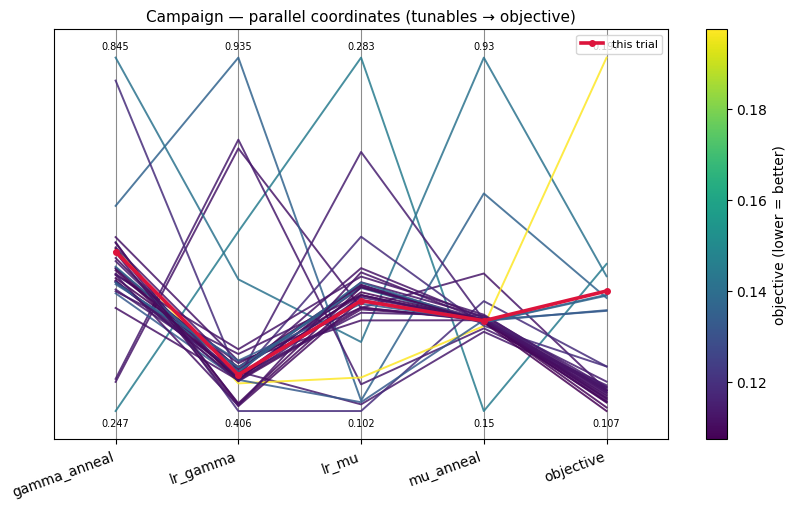

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 34 ran the highest-EI candidate (candidate 8, ei=3.64): `lr_mu=0.1587`, `mu_anneal=0.3492` (effective mu travel 0.131), `lr_gamma=0.4599`, `gamma_anneal=0.5168`. It completed in 7.2 min with objective **0.1380 +/- 0.0972** and **1 diverged cell** (1nW T05: gamma 1.76e14). Ranking: trial_21 0.1074 < ... < **trial_34 0.1380** < ...

Aggregate accuracy: **mu rel-RMSE 72.6%** (RMSE 27.77, bias -5.34) — the other seven cells were normal; gamma dominated by the diverged cell (raw RMSE 6.2e13).

Per-cell relative errors (1nW T05 gamma is the diverged value):
- **mu:** 1nW T05 -8.2%, T20 +140.8%, T60 -6.4%, T100 -7.2% | 3nW T05 +134.6%, T20 +45.6%, T60 -23.9%, T100 -37.6%.
- **gamma:** 1nW T05 **diverged (1.76e14)**, T20 -26.7%, T60 -11.4%, T100 -1.2% | 3nW T05 -30.5%, T20 -8.3%, T60 +4.1%, T100 +0.1%.

Another optimum-band sample (travel 0.131) that diverged at 1nW T05 with the other cells normal. The tally in the optimum band is now **seven survivals** below 0.111 (0.1074-0.1106) versus **four divergences** (trials 26, 28, 29, 34, all ~0.133-0.138), i.e. the low-count blow-up hits roughly one in three runs at essentially the same schedule. This fully establishes that the 1nW T05 divergence is the dominant, non-tunable source of objective variance (worth ~0.02-0.07 per affected run) and that the achievable schedule level is ~0.108. trial_21 (0.1074) remains the best.

**Summary:** Trial 34 (lr_mu=0.1587, mu_anneal=0.3492, lr_gamma=0.4599, gamma_anneal=0.5168): objective 0.1380 +/- 0.0972 with 1 diverged cell (1nW T05, gamma 1.8e14); another optimum-region divergence, keeping the rate at roughly one in three and leaving trial_21 (0.1074) as best.
**Key insight:** The optimum band has now produced seven sub-0.111 survivals and four divergences (26, 28, 29, 34) at near-identical schedules, so the 1nW T05 gamma blow-up is confirmed to be a coin-flip hazard and the schedule search itself is exhausted at ~0.108.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
**Notes for Anuar (not acted on).** The single highest-value change remains a structural fix for the low-count gamma divergence; every hyperparameter configuration tested has the same hazard. Recorded only, not acted on.


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = "Trial 34 (lr_mu=0.1587, mu_anneal=0.3492, lr_gamma=0.4599, gamma_anneal=0.5168): objective 0.1380 +/- 0.0972 with 1 diverged cell (1nW T05, gamma 1.8e14); another optimum-region divergence, keeping the rate at roughly one in three and leaving trial_21 (0.1074) as best"      # [Put the one-line summary here: copy it from cell 6]
KEY_INSIGHT = "The optimum band has now produced seven sub-0.111 survivals and four divergences (26, 28, 29, 34) at near-identical schedules, so the 1nW T05 gamma blow-up is confirmed to be a coin-flip hazard and the schedule search itself is exhausted at ~0.108"  # [Put the one-sentence key insight here: copy it from cell 6]


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_34 | current best: trial_21


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_35.ipynb. Open it and follow its cells from the top.
